In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt

# Project root directory
# Корневая директория проекта
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

# Make src importable and load reusable feature helpers
# Делаем src импортируемым и подключаем переиспользуемые функции
sys.path.insert(0, str(ROOT))
from src.features import (split_genres, split_tags, count_tags,
                          review_length, extract_top_bigrams, hours_played)

# Plot style
# Стиль графиков
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(DATA, DATA.exists())

/home/mchunikhin/project_steam_game_recomm_system/data True


## Reviews → Interactions

The raw review dataset is highly sparse, so we first build a clean interaction table for recommendation models.

### Processing Steps

- Keep reviews within the selected time window.
- Remove duplicate user-game pairs by keeping the most recent review.
- Filter low-activity users and low-popularity games.
- Apply iterative k-core filtering until the dataset stabilizes.

### Output

`interactions.parquet`

One row corresponds to one user-game interaction.

## Отзывы → Взаимодействия

Исходный датасет отзывов сильно разрежен, поэтому сначала формируем чистую таблицу взаимодействий для рекомендательных моделей.

### Этапы обработки

- Оставляем отзывы только за выбранный период.
- Для каждой пары пользователь–игра сохраняем только последний отзыв.
- Удаляем малоактивных пользователей и игры с небольшим числом отзывов.
- Выполняем итеративную k-core фильтрацию до стабилизации выборки.

### Результат

`interactions.parquet`

Одна строка соответствует одному взаимодействию пользователь–игра.

In [2]:
# Set True to rebuild from raw CSV, ignoring the cache
# True — пересобрать из сырых CSV, игнорируя кэш
REBUILD = False

# Filtering parameters (fixed for the project)
# Параметры фильтрации (зафиксированы для проекта)
WINDOW_START = int(datetime(2020, 1, 1, tzinfo=timezone.utc).timestamp())  # 2020-01-01
MIN_GAME_REVIEWS = 20
MIN_USER_INTER = 5
REVIEW_COLS = ["steamid", "appid", "voted_up", "playtime_forever",
               "unix_timestamp_created"]

out = DATA / "processed" / "interactions.parquet"
if out.exists() and not REBUILD:
    # Load cached interactions if available
    # Загружаем готовые взаимодействия из кэша
    inter = pd.read_parquet(out)
    print("loaded from cache:", out, f"({len(inter):,} rows)")
else:
    # Read reviews in chunks, keep only the time window and needed columns
    # Читаем отзывы чанками, оставляем только нужное окно и колонки
    parts = []
    for f in sorted((DATA / "reviews").glob("reviews-*.csv")):
        for ch in pd.read_csv(f, usecols=REVIEW_COLS, chunksize=3_000_000):
            ch = ch[ch["unix_timestamp_created"] >= WINDOW_START]
            if len(ch):
                parts.append(ch)
    inter = pd.concat(parts, ignore_index=True)
    del parts
    print("within window:", f"{len(inter):,}")

    # Remove duplicate user-game pairs, keep the most recent review
    # Удаляем дубликаты пользователь–игра, оставляем последний отзыв
    inter = (inter.sort_values("unix_timestamp_created")
                  .drop_duplicates(["steamid", "appid"], keep="last"))
    print("after dedup:", f"{len(inter):,}")

    # Iterative k-core filtering until the sets stabilize
    # Итеративная k-core фильтрация до стабилизации выборки
    while True:
        n0 = len(inter)
        g_ok = inter["appid"].value_counts()
        inter = inter[inter["appid"].isin(g_ok[g_ok >= MIN_GAME_REVIEWS].index)]
        u_ok = inter["steamid"].value_counts()
        inter = inter[inter["steamid"].isin(u_ok[u_ok >= MIN_USER_INTER].index)]
        if len(inter) == n0:
            break

    # Build the final interactions table (label = voted_up: recommended or not)
    # Формируем итоговую таблицу взаимодействий (label = voted_up: рекомендует или нет)
    inter = inter.rename(columns={"steamid": "user_id", "appid": "game_id",
                                  "voted_up": "label"})
    inter["label"] = inter["label"].astype("int8")

    # Save processed dataset
    # Сохраняем обработанный датасет
    inter.to_parquet(out, index=False)
    print("saved:", out, f"({out.stat().st_size/1e6:.1f} MB)")

print("\nSummary")
print("interactions:", f"{len(inter):,}")
print("games:       ", f"{inter['game_id'].nunique():,}")
print("users:       ", f"{inter['user_id'].nunique():,}")

loaded from cache: /home/mchunikhin/project_steam_game_recomm_system/data/processed/interactions.parquet (901,137 rows)

Summary
interactions: 901,137
games:        2,872
users:        113,552


## Games Metadata

Game metadata is used as item features for content-based models, the item tower and the ranking stage.

### Processing Steps

- Load only the required columns.
- Remove duplicate AppIDs.
- Keep only games present in the interaction dataset.
- Save the processed table.

### Note

The header merges `Discount` and `DLC count` into one name (39 names vs 40 data fields),
so it must be split back; otherwise every column after it shifts and `Genres`/`Tags` get wrong values.

### Output

`games.parquet`

Processed item features table.

## Метаданные игр

Метаданные игр используются как признаки для content-based моделей, item tower и этапа ранжирования.

### Этапы обработки

- Загружаем только необходимые столбцы.
- Удаляем дубликаты AppID.
- Оставляем только игры, присутствующие в таблице взаимодействий.
- Сохраняем обработанную таблицу.

### Важно

В шапке склеены `Discount` и `DLC count` (39 имён против 40 полей данных), поэтому имя нужно
разделить обратно; иначе все колонки после неё съезжают и `Genres`/`Tags` получают неверные значения.

### Результат

`games.parquet`

Таблица признаков игр для последующих этапов пайплайна.

In [3]:
# Columns to keep as item features
# Колонки, которые оставляем как признаки игр
GAME_COLS = ["AppID", "Name", "Release date", "Estimated owners", "Price",
             "Positive", "Negative", "Genres", "Tags", "Categories",
             "Average playtime forever", "Median playtime forever"]

out_g = DATA / "processed" / "games.parquet"
if out_g.exists() and not REBUILD:
    # Load cached games metadata if available
    # Загружаем готовые метаданные игр из кэша
    games_f = pd.read_parquet(out_g)
    print("loaded from cache:", out_g, f"({len(games_f):,} games)")
else:
    # The header merges "Discount" and "DLC count" into one name (39 names vs 40
    # data fields), which shifts every column after it -> split the name back.
    # В шапке склеены "Discount" и "DLC count" (39 имён против 40 полей),
    # из-за чего все колонки после неё съезжают -> разделяем имя обратно.
    csv_path = DATA / "games" / "games.csv"
    raw_cols = pd.read_csv(csv_path, nrows=0).columns.tolist()
    i = raw_cols.index("DiscountDLC count")
    fixed_cols = raw_cols[:i] + ["Discount", "DLC count"] + raw_cols[i + 1:]

    # Read with fixed names; index_col=False keeps the leading columns aligned
    # Читаем с исправленными именами; index_col=False держит начало ровно
    games = pd.read_csv(csv_path, names=fixed_cols, header=0,
                        index_col=False, usecols=GAME_COLS)

    # Keep only games present in interactions, drop duplicate AppIDs
    # Оставляем только игры из interactions, удаляем дубликаты AppID
    keep_ids = inter["game_id"].unique()
    games_f = (games.drop_duplicates("AppID")
               .loc[lambda d: d["AppID"].isin(keep_ids)]
               .rename(columns={"AppID": "game_id"})
               .reset_index(drop=True))

    # Save processed dataset
    # Сохраняем обработанный датасет
    games_f.to_parquet(out_g, index=False)
    print("games in interactions:", f"{len(keep_ids):,}")
    print("without metadata:     ", f"{len(set(keep_ids) - set(games_f['game_id'])):,}")
    print("saved:", out_g, f"({out_g.stat().st_size/1e6:.1f} MB)")

print("games with metadata:", f"{len(games_f):,}")

loaded from cache: /home/mchunikhin/project_steam_game_recomm_system/data/processed/games.parquet (2,759 games)
games with metadata: 2,759


## Exploratory Analysis for Recommendation Modeling

Each part of this analysis is tied to a later modeling decision (baselines, retrieval, ranking),
not just plotted for its own sake.

## Разведочный анализ для рекомендательных моделей

Каждый раздел анализа связан с конкретным решением в моделировании (baselines, retrieval, ranking),
а не построен просто ради графика.

### 1. Dataset Overview

Scale of the data and average activity per user — this guides model choice.

### 1. Обзор датасета

Масштаб данных и средняя активность на пользователя — это влияет на выбор моделей.

> _Conclusion: to be added. / Вывод: будет добавлен._

interactions                 901137.00
users                        113552.00
games                          2872.00
avg interactions per user         7.94


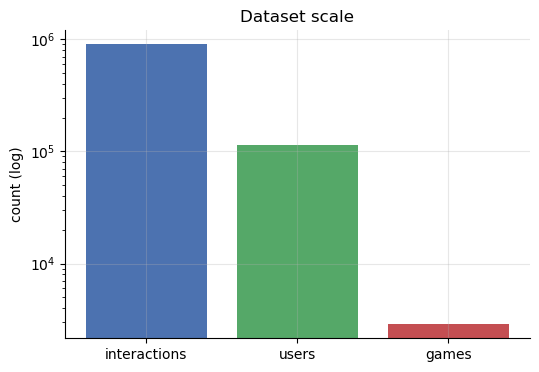

In [4]:
# Dataset overview
# Обзор датасета
overview = pd.Series({
    "interactions": len(inter),
    "users": inter["user_id"].nunique(),
    "games": inter["game_id"].nunique(),
    "avg interactions per user": round(len(inter) / inter["user_id"].nunique(), 2),
})
print(overview.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["interactions", "users", "games"],
       [len(inter), inter["user_id"].nunique(), inter["game_id"].nunique()],
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("count (log)")
ax.set_title("Dataset scale")
plt.show()

### 2. User Activity

Distribution of interactions per user. Used later for ALS, Two-Tower and the leave-last-out split.

### 2. Активность пользователей

Распределение числа взаимодействий на пользователя. Пригодится для ALS, Two-Tower и split leave-last-out.

> _Conclusion: to be added. / Вывод: будет добавлен._

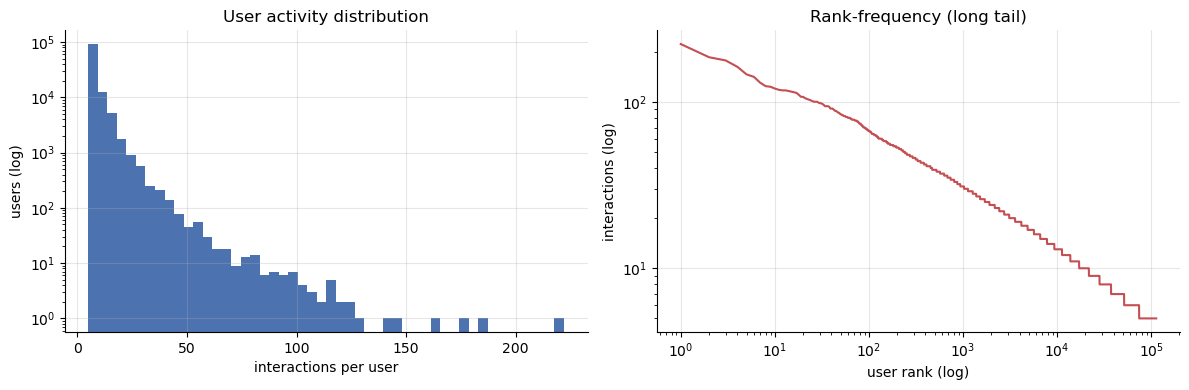

percentiles: {0.5: 6, 0.9: 12, 0.99: 29}


In [5]:
# Interactions per user (long tail)
# Взаимодействий на пользователя (длинный хвост)
upc = inter["user_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(upc, bins=50, color="#4C72B0")
axes[0].set_yscale("log")
axes[0].set_xlabel("interactions per user")
axes[0].set_ylabel("users (log)")
axes[0].set_title("User activity distribution")

ranked = upc.sort_values(ascending=False).values
axes[1].plot(range(1, len(ranked) + 1), ranked, color="#C44E52")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("user rank (log)")
axes[1].set_ylabel("interactions (log)")
axes[1].set_title("Rank-frequency (long tail)")
plt.tight_layout()
plt.show()

print("percentiles:", upc.quantile([0.5, 0.9, 0.99]).astype(int).to_dict())

### 3. Game Popularity

Distribution of reviews per game. Explains why the Popularity baseline works and feeds candidate retrieval.

### 3. Популярность игр

Распределение числа отзывов на игру. Объясняет, почему работает Popularity baseline, и питает candidate retrieval.

> _Conclusion: to be added. / Вывод: будет добавлен._

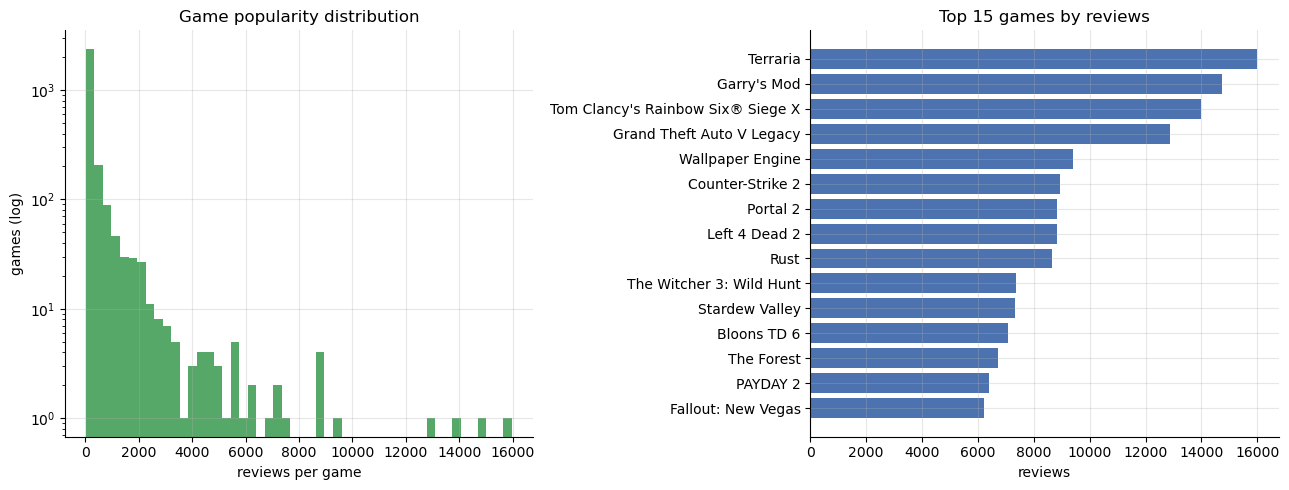

In [6]:
# Reviews per game and top games
# Отзывов на игру и топ-игры
gpc = inter["game_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(gpc, bins=50, color="#55A868")
axes[0].set_yscale("log")
axes[0].set_xlabel("reviews per game")
axes[0].set_ylabel("games (log)")
axes[0].set_title("Game popularity distribution")

top = gpc.head(15).sort_values()
names = games_f.set_index("game_id")["Name"].reindex(top.index)
names = names.fillna(pd.Series(top.index.astype(str), index=top.index))
axes[1].barh(names.values, top.values, color="#4C72B0")
axes[1].set_xlabel("reviews")
axes[1].set_title("Top 15 games by reviews")
plt.tight_layout()
plt.show()

### 4. Genres

Genre frequency. Later used for genre overlap in Content-Based and the Item Tower.

### 4. Жанры

Частота жанров. Дальше используется для genre overlap в Content-Based и Item Tower.

> _Conclusion: to be added. / Вывод: будет добавлен._

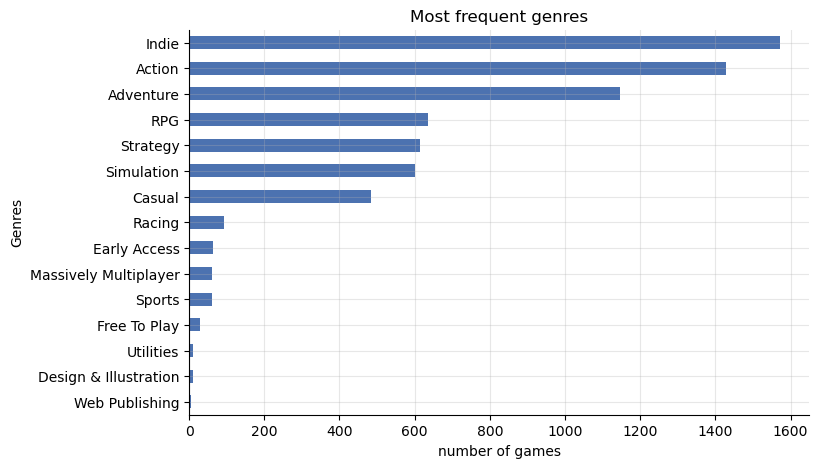

games without genres: 3


In [7]:
# Genre frequency
# Частота жанров
genres = split_genres(games_f["Genres"]).explode()
genres = genres[genres != ""]
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_genres.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("number of games")
ax.set_title("Most frequent genres")
plt.show()

print("games without genres:", int((split_genres(games_f["Genres"]).apply(len) == 0).sum()))

### 5. Tags

Tags are central on Steam. We look at the most frequent tags and how many tags a game has.
Later used for tag overlap in Content-Based, the Item Tower and the Ranker.

### 5. Теги

Теги — основа Steam. Смотрим самые частые теги и сколько тегов у игры.
Дальше используется для tag overlap в Content-Based, Item Tower и Ranker.

> _Conclusion: to be added. / Вывод: будет добавлен._

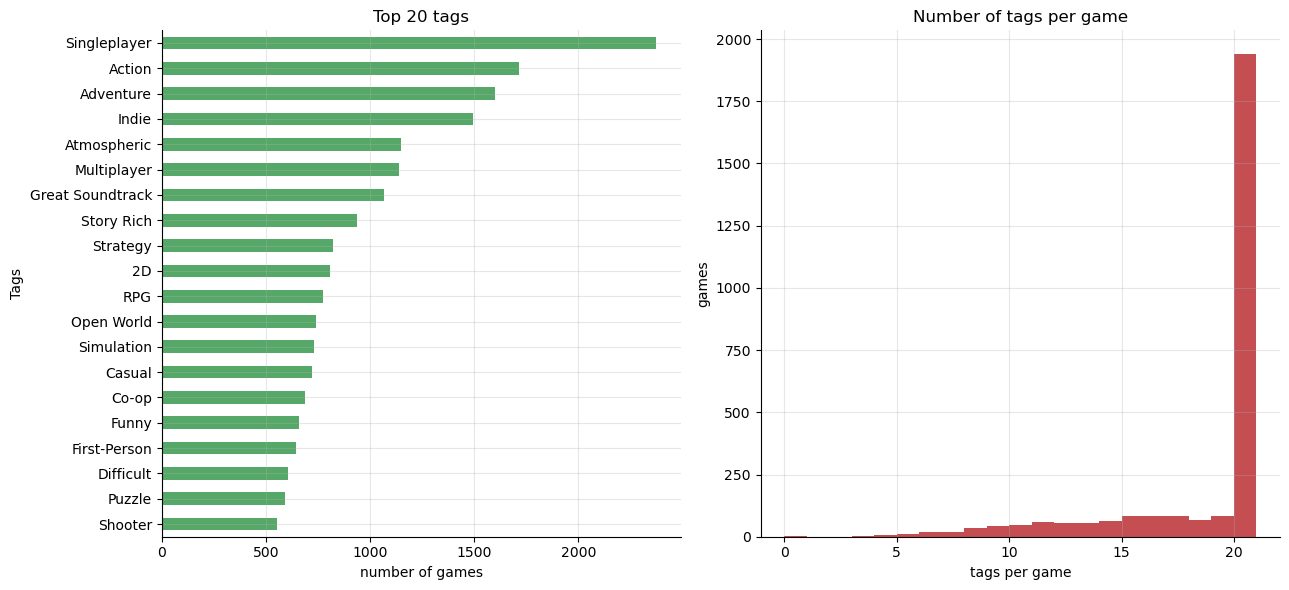

median tags per game: 20 | games without tags: 3


In [8]:
# Tag frequency and number of tags per game
# Частота тегов и число тегов на игру
games_f["n_tags"] = count_tags(games_f["Tags"])
tags = split_tags(games_f["Tags"]).explode()
tags = tags[tags != ""]
top_tags = tags.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top_tags.sort_values().plot.barh(ax=axes[0], color="#55A868")
axes[0].set_xlabel("number of games")
axes[0].set_title("Top 20 tags")

axes[1].hist(games_f["n_tags"], bins=range(0, int(games_f["n_tags"].max()) + 2), color="#C44E52")
axes[1].set_xlabel("tags per game")
axes[1].set_ylabel("games")
axes[1].set_title("Number of tags per game")
plt.tight_layout()
plt.show()

print("median tags per game:", int(games_f["n_tags"].median()),
      "| games without tags:", int((games_f["n_tags"] == 0).sum()))

### 6. Feature Candidates

A first map of which raw signals become features in later stages.

| Feature | Later used in |
|---|---|
| Genres | Content-Based, Item Tower |
| Tags | Content-Based, Item Tower, Ranker |
| Price | LambdaMART (Ranker) |
| Playtime | Weighted review embeddings |
| Review text | Sentence Transformers |
| Popularity | Popularity baseline, Ranker |
| Label (recommended) | ALS, Two-Tower |

### 6. Кандидаты в признаки

Первая карта того, какие сырые сигналы станут признаками на следующих этапах.

| Признак | Где используется дальше |
|---|---|
| Жанры | Content-Based, Item Tower |
| Теги | Content-Based, Item Tower, Ranker |
| Цена | LambdaMART (Ranker) |
| Время игры | Взвешенные эмбеддинги отзывов |
| Текст отзывов | Sentence Transformers |
| Популярность | Popularity baseline, Ranker |
| Метка (recommended) | ALS, Two-Tower |

### 7. Prices

Price distribution and the share of free vs paid games. Price will later be a Ranker feature.

### 7. Цены

Распределение цен и доля бесплатных vs платных игр. Цена позже станет признаком в Ranker.

> _Conclusion: to be added. / Вывод: будет добавлен._

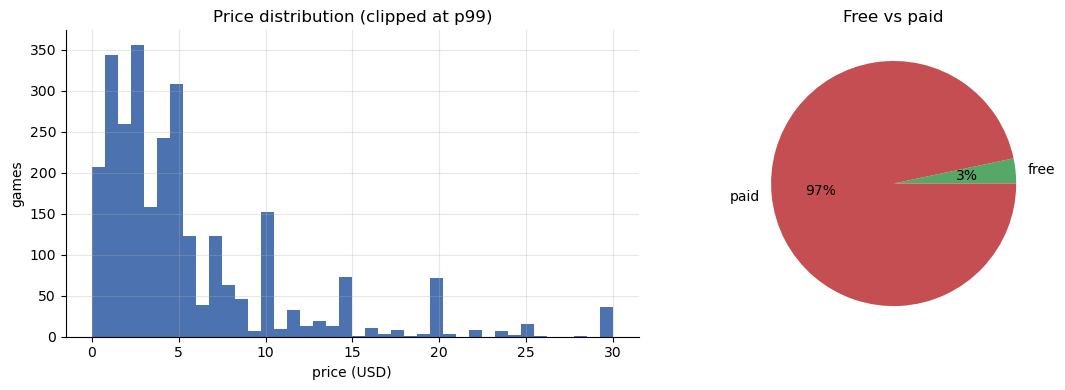

free share: 3.3% | median paid price: 3.99


In [9]:
# Price distribution and free vs paid
# Распределение цен и free vs paid
price = games_f["Price"].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price.clip(upper=price.quantile(0.99)), bins=40, color="#4C72B0")
axes[0].set_xlabel("price (USD)")
axes[0].set_ylabel("games")
axes[0].set_title("Price distribution (clipped at p99)")

free = int((price == 0).sum())
paid = int((price > 0).sum())
axes[1].pie([free, paid], labels=["free", "paid"], autopct="%1.0f%%",
            colors=["#55A868", "#C44E52"])
axes[1].set_title("Free vs paid")
plt.tight_layout()
plt.show()

print("free share:", f"{(price == 0).mean():.1%}",
      "| median paid price:", round(price[price > 0].median(), 2))

### 8. Playtime

Distribution of playtime per interaction (in hours).

Most users spend relatively little time in a game, while a small fraction accumulates hundreds of hours.
This motivates weighting review embeddings by `weight = log1p(playtime)`, so that reviews from highly
engaged players influence the game embedding more than reviews after a few minutes.

### 8. Время игры

Распределение времени игры на взаимодействие (в часах).

Большинство пользователей проводят в игре относительно мало времени, тогда как небольшая доля
набирает сотни часов. Это мотивирует взвешивать эмбеддинги отзывов как `weight = log1p(playtime)`,
чтобы отзывы вовлечённых игроков влияли на эмбеддинг игры сильнее, чем отзывы после пары минут.

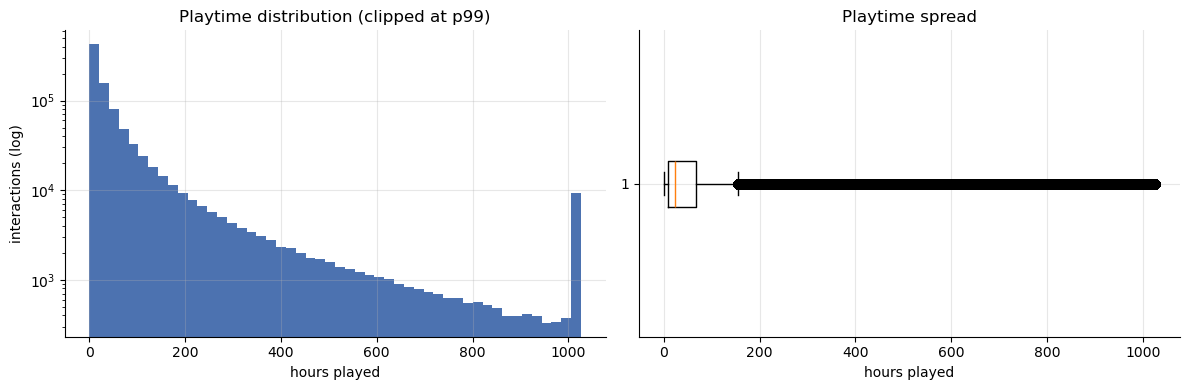

median hours: 22.9 | mean hours: 84.8 | p99 hours: 1026.4


In [10]:
# Playtime distribution (hours)
# Распределение времени игры (часы)
hours = hours_played(inter["playtime_forever"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hours.clip(upper=hours.quantile(0.99)), bins=50, color="#4C72B0")
axes[0].set_yscale("log")
axes[0].set_xlabel("hours played")
axes[0].set_ylabel("interactions (log)")
axes[0].set_title("Playtime distribution (clipped at p99)")

axes[1].boxplot(hours.clip(upper=hours.quantile(0.99)), vert=False)
axes[1].set_xlabel("hours played")
axes[1].set_title("Playtime spread")
plt.tight_layout()
plt.show()

print("median hours:", round(hours.median(), 1),
      "| mean hours:", round(hours.mean(), 1),
      "| p99 hours:", round(hours.quantile(0.99), 1))

### 9. Positive Rate

Share of positive (`recommended`) interactions — this becomes the `label` for ALS, Two-Tower and the Ranker.

The dataset is highly imbalanced toward positive recommendations, making ranking metrics
(Recall@K, NDCG@K, MAP@K) more informative than classification accuracy.

### 9. Доля положительных

Доля положительных (`recommended`) взаимодействий — это становится `label` для ALS, Two-Tower и Ranker.

Датасет сильно смещён в сторону положительных рекомендаций, поэтому ранжирующие метрики
(Recall@K, NDCG@K, MAP@K) информативнее, чем accuracy классификации.

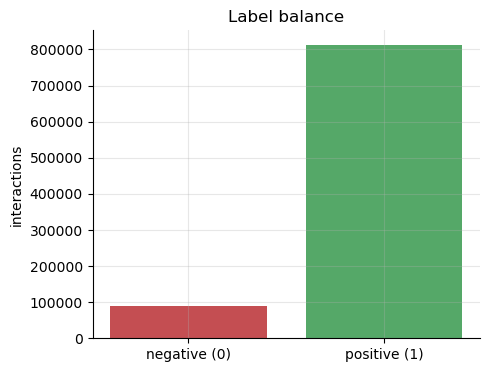

positive share: 90.2%


In [11]:
# Label balance (recommended vs not)
# Баланс меток (рекомендует / нет)
counts = inter["label"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["negative (0)", "positive (1)"], counts.values, color=["#C44E52", "#55A868"])
ax.set_ylabel("interactions")
ax.set_title("Label balance")
plt.show()

print("positive share:", f"{inter['label'].mean():.1%}")

### Review Text Analysis

Here we read a small sample of raw review text — only for the games that are present in `interactions`,
so the text analysis matches the same games the models will be trained on. We look at review length
and the most frequent bigrams.

### Анализ текста отзывов

Здесь читаем небольшой сэмпл сырого текста отзывов — только для игр, которые есть в `interactions`,
чтобы анализ текста относился к тем же играм, на которых будут обучаться модели. Смотрим длину
отзывов и самые частые биграммы.

> _Conclusion: to be added. / Вывод: будет добавлен._

In [12]:
# Sample raw reviews only from games present in interactions
# Сэмплируем сырые отзывы только из игр, попавших в interactions
keep = set(inter["game_id"].unique())
SAMPLE_N = 120_000

parts = []
for f in sorted((DATA / "reviews").glob("reviews-*.csv")):
    for ch in pd.read_csv(f, usecols=["appid", "review", "unix_timestamp_created"],
                          chunksize=2_000_000):
        ch = ch[(ch["unix_timestamp_created"] >= WINDOW_START) & ch["appid"].isin(keep)]
        if len(ch):
            parts.append(ch["review"])
reviews_text = pd.concat(parts, ignore_index=True).dropna().astype(str)
reviews_text = reviews_text[reviews_text.str.strip() != ""]
reviews_text = reviews_text.sample(min(SAMPLE_N, len(reviews_text)), random_state=42)
del parts
print("review text sample:", f"{len(reviews_text):,}")

review text sample: 120,000


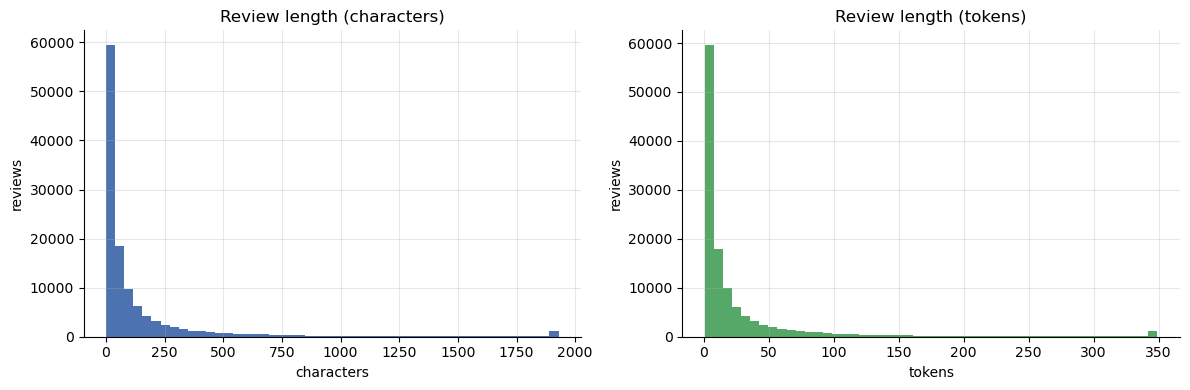

median chars: 40 | median tokens: 8 | p95 tokens: 122


In [13]:
# Review length in characters and tokens
# Длина отзывов в символах и токенах
chars = review_length(reviews_text, unit="chars")
tokens = review_length(reviews_text, unit="tokens")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(chars.clip(upper=chars.quantile(0.99)), bins=50, color="#4C72B0")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("reviews")
axes[0].set_title("Review length (characters)")

axes[1].hist(tokens.clip(upper=tokens.quantile(0.99)), bins=50, color="#55A868")
axes[1].set_xlabel("tokens")
axes[1].set_ylabel("reviews")
axes[1].set_title("Review length (tokens)")
plt.tight_layout()
plt.show()

print("median chars:", int(chars.median()),
      "| median tokens:", int(tokens.median()),
      "| p95 tokens:", int(tokens.quantile(0.95)))

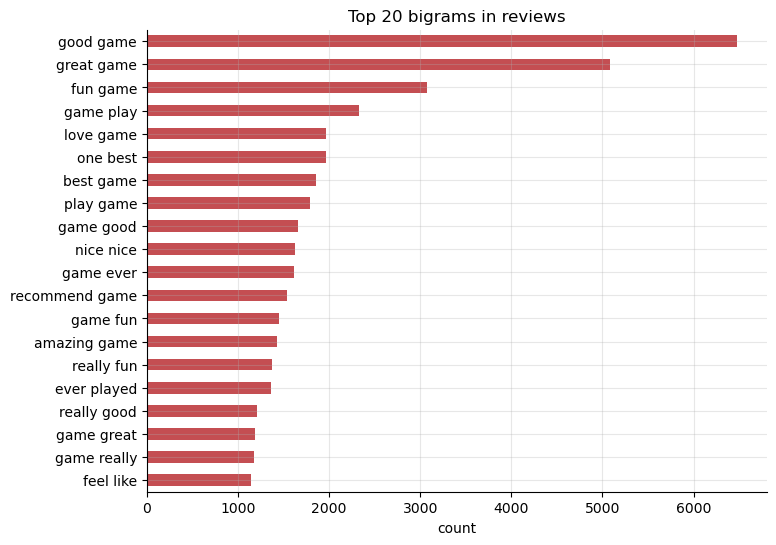

In [14]:
# Most frequent bigrams (stopwords removed)
# Самые частые биграммы (стоп-слова удалены)
top_bigrams = extract_top_bigrams(reviews_text, n=20)
bg = pd.Series({f"{a} {b}": c for (a, b), c in top_bigrams})

fig, ax = plt.subplots(figsize=(8, 6))
bg.sort_values().plot.barh(ax=ax, color="#C44E52")
ax.set_xlabel("count")
ax.set_title("Top 20 bigrams in reviews")
plt.show()

## Next Step

The exploratory analysis confirmed that the processed dataset is suitable for building recommendation models.

The next notebook focuses on data validation and the leave-last-out evaluation split.

## Следующий этап

Исследовательский анализ подтвердил, что обработанный датасет подходит для построения рекомендательных моделей.

В следующем ноутбуке выполняется проверка качества данных и формирование leave-last-out разбиения.